# **Importing Modules**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import PIL
import tensorflow as tf
from pathlib import Path
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'chest_xray').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_ROOT = PROJECT_ROOT / 'data' / 'chest_xray'
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f'Dataset not found at {DATASET_ROOT}')

2024-03-21 00:03:34.404002: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-21 00:03:34.404173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-21 00:03:34.599962: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# **Loading Data**

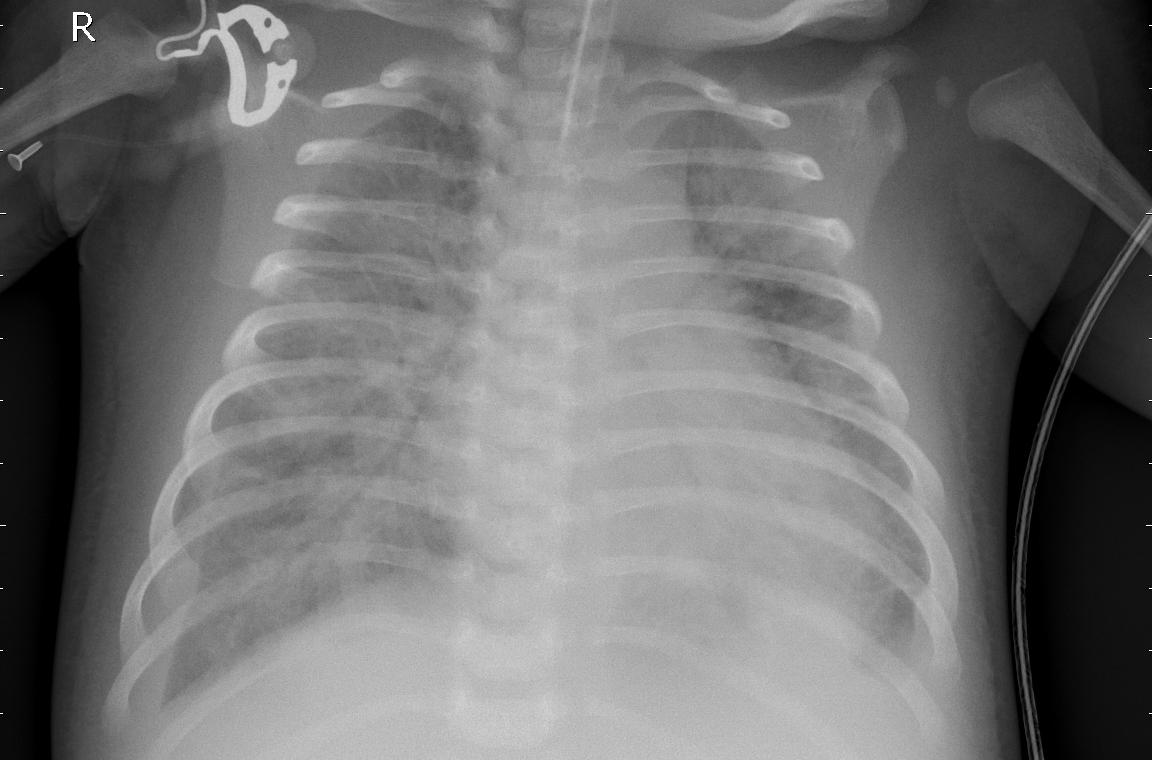

In [2]:
image = PIL.Image.open(DATASET_ROOT / 'train' / 'PNEUMONIA' / 'person1000_bacteria_2931.jpeg')
image

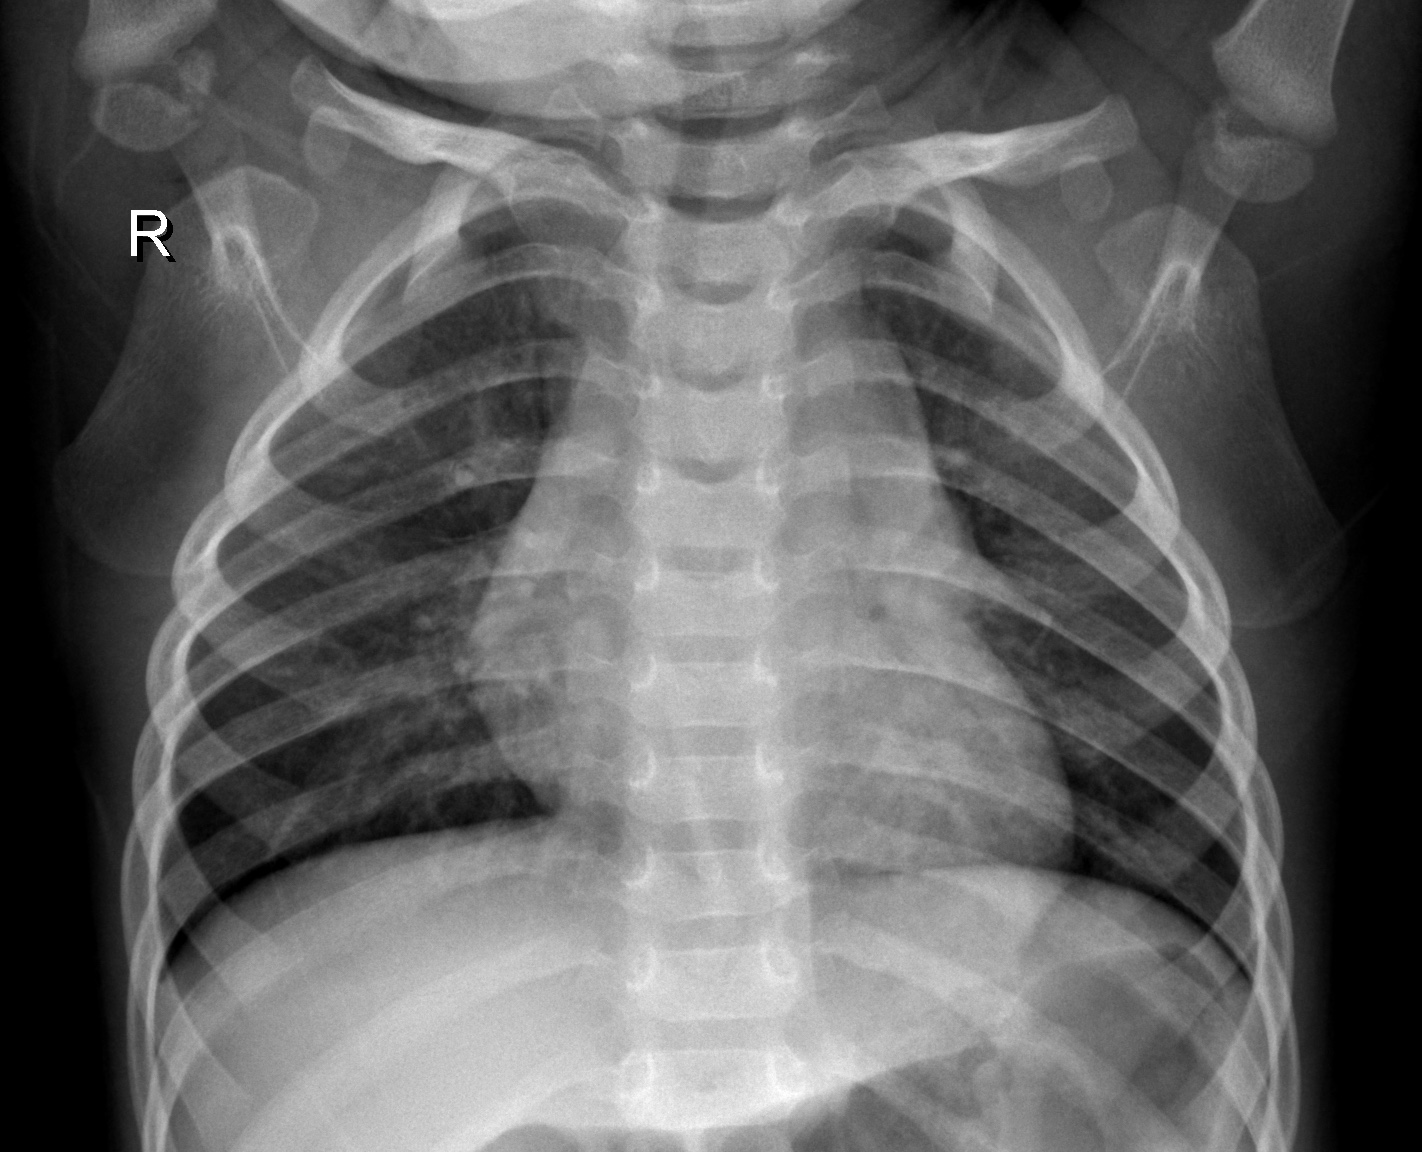

In [3]:
image_normal = PIL.Image.open(DATASET_ROOT / 'train' / 'NORMAL' / 'IM-0117-0001.jpeg')
image_normal

In [4]:
train_dir = str(DATASET_ROOT / 'train')
training_generator = ImageDataGenerator(rescale = 1/255)
train_data = training_generator.flow_from_directory(train_dir, target_size=(120,120), batch_size=8, class_mode='binary')

Found 5216 images belonging to 2 classes.


In [5]:
valid_dir = str(DATASET_ROOT / 'val')
validation_generator = ImageDataGenerator(rescale = 1/255)
valid_data = validation_generator.flow_from_directory(valid_dir, target_size=(120,120), batch_size=8, class_mode='binary')

Found 16 images belonging to 2 classes.


In [6]:
test_dir = str(DATASET_ROOT / 'test')
testing_generator = ImageDataGenerator(rescale = 1/255)
test_data = testing_generator.flow_from_directory(test_dir, target_size=(120,120), batch_size=8, class_mode='binary')

Found 624 images belonging to 2 classes.


# **CNN**

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), input_shape=(120,120,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(256, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(512, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 118, 118, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 59, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 57, 57, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,700,161 (6.49 MB)

 Trainable params: 1,700,161 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['acc'])

In [10]:
history = model.fit(train_data, epochs=10, validation_data=valid_data)

Epoch 1/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 131s 195ms/step - acc: 0.7476 - loss: 0.5659 - val_acc: 0.8125 - val_loss: 0.3604
Epoch 2/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 112s 171ms/step - acc: 0.9138 - loss: 0.2233 - val_acc: 0.8750 - val_loss: 0.4323
Epoch 3/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 112s 171ms/step - acc: 0.9485 - loss: 0.1364 - val_acc: 0.9375 - val_loss: 0.2005
Epoch 4/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 142s 171ms/step - acc: 0.9633 - loss: 0.1002 - val_acc: 0.6250 - val_loss: 0.7386
Epoch 5/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 141s 170ms/step - acc: 0.9700 - loss: 0.0852 - val_acc: 0.8750 - val_loss: 0.3765
Epoch 6/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 143s 172ms/step - acc: 0.9612 - loss: 0.1037 - val_acc: 0.7500 - val_loss: 0.6944
Epoch 7/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 112s 171ms/step - acc: 0.9699 - loss: 0.0750 - val_acc: 0.7500 - val_loss: 0.5165
Epoch 8/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 113s 172ms/step - acc: 0.9790 - loss: 0.0477 - val_acc: 0.8750 - val_loss: 0.5073
Epoch 9/10
652/652 ━━━━━

In [11]:
model.evaluate(test_data)

78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - acc: 0.7447 - loss: 1.1615


[0.942505955696106, 0.7900640964508057]

In [12]:
predictions = model.predict(test_data)

78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


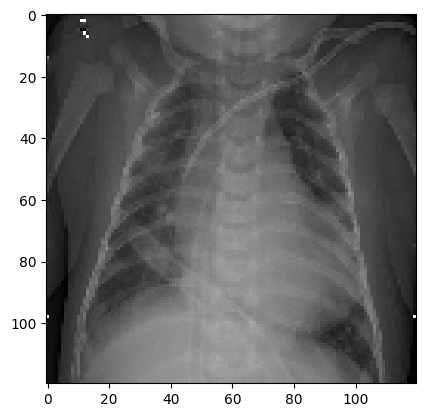

The probability of Pneumonia is:  [0.99804807]


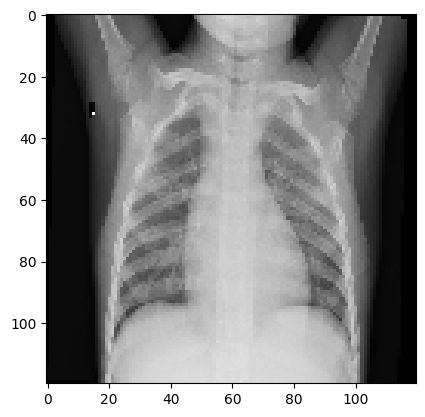

The probability of Pneumonia is:  [0.8907589]


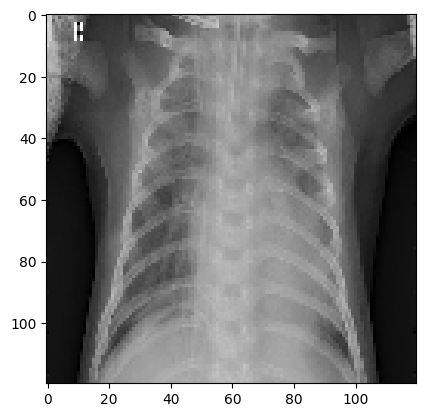

The probability of Pneumonia is:  [0.9999997]


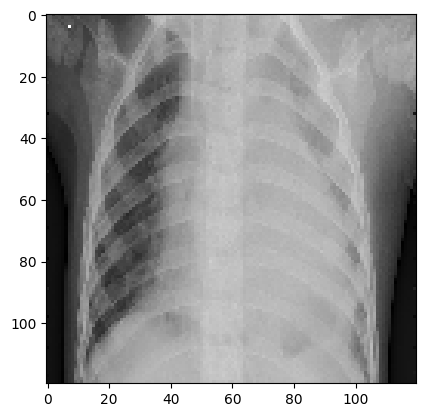

The probability of Pneumonia is:  [1.]


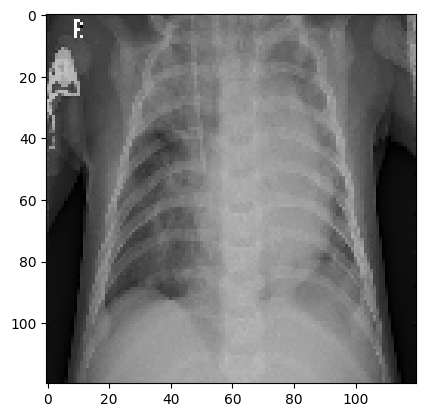

The probability of Pneumonia is:  [1.]


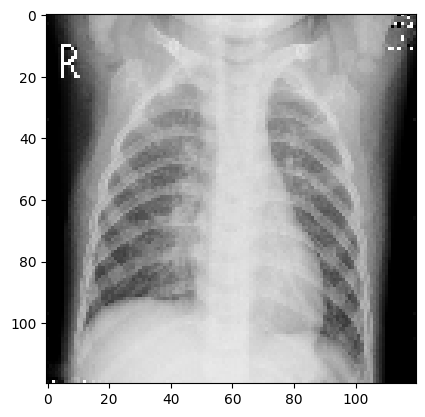

The probability of Pneumonia is:  [0.99996877]


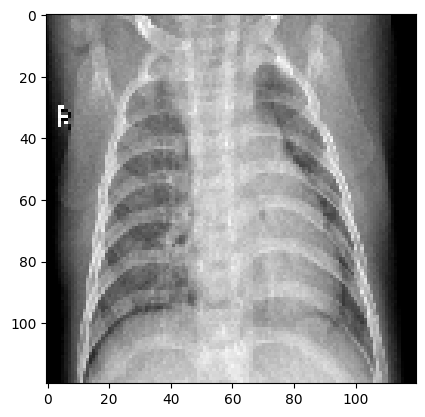

The probability of Pneumonia is:  [0.99962467]


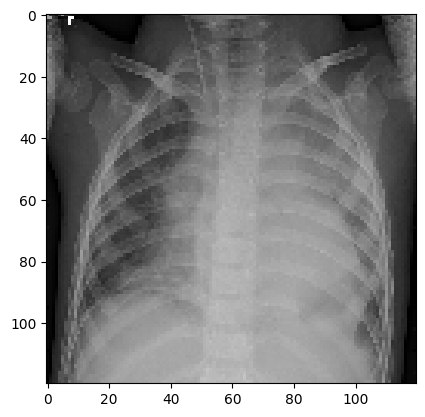

The probability of Pneumonia is:  [0.99999887]


In [13]:
batch_size = test_data.batch_size
num_batches = 1

for i in range(num_batches):
    x, y = next(test_data)
    predictions = model.predict(x)
    
    for j in range(min(batch_size, 8)):
        image = x[j]
        plt.imshow(image)
        plt.show()
        print('The probability of Pneumonia is: ', predictions[j])